Dataset Shape: (50000, 11)

MODEL PERFORMANCE
Accuracy: 0.9968795007201152
Precision: 0.9985412107950401
Recall: 0.9951538647928277
F1 Score: 0.9968446601941747

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4205
           1       1.00      1.00      1.00      4127

    accuracy                           1.00      8332
   macro avg       1.00      1.00      1.00      8332
weighted avg       1.00      1.00      1.00      8332



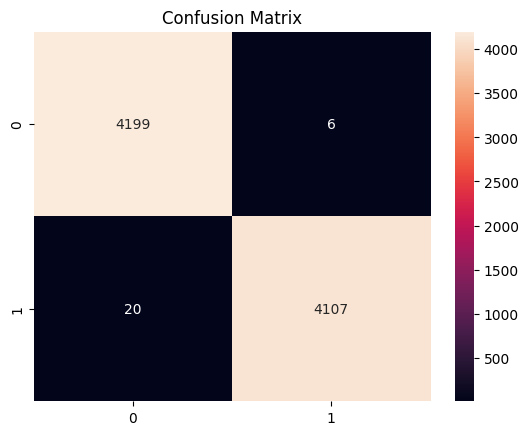


Feature Importance

            Feature  Importance
7   tweet_frequency    0.919981
8    night_activity    0.069927
5  engagement_ratio    0.002501
0    Follower Count    0.002470
4        engagement    0.001436
1     Retweet Count    0.001355
6      posting_hour    0.001350
2     Mention Count    0.000661
3          Verified    0.000318


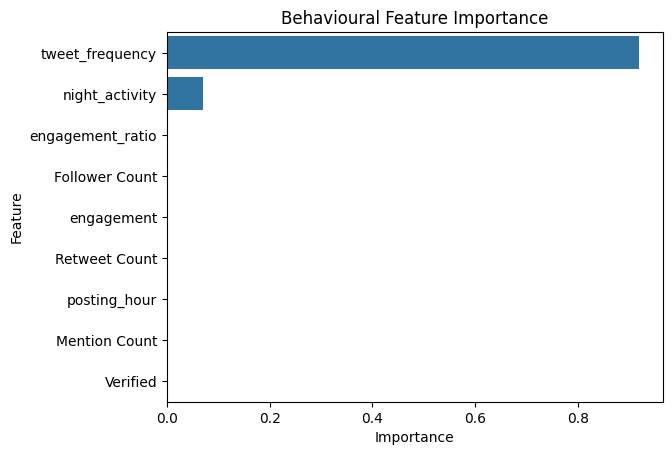

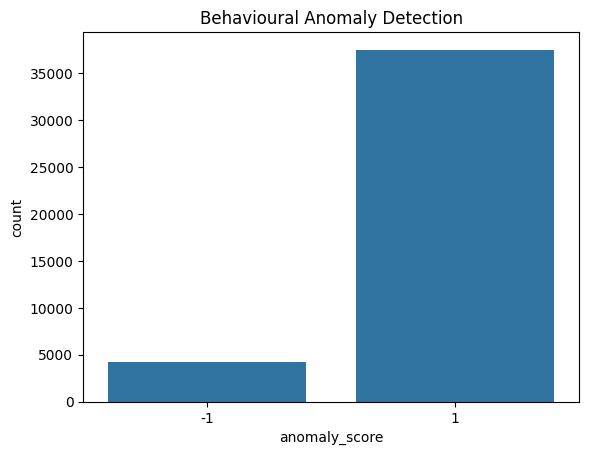


Sample Output

   Bot Prediction  Bot Probability  Authenticity Score
0               1         0.991645            0.008355
1               0         0.002021            0.997979
2               0         0.011939            0.988061
3               1         0.989439            0.010561
4               1         0.992962            0.007038

Model Saved Successfully


In [34]:
# ================================
# STEP 1: Import Libraries
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib


# ================================
# STEP 2: Load Dataset
# ================================

data = pd.read_csv("bot_detection_data.csv")

print("Dataset Shape:", data.shape)

data = data.dropna()


# ================================
# STEP 3: Basic Behaviour Features
# ================================

# Convert verified to numeric

data['Verified'] = data['Verified'].astype(int)


# Convert Created At to datetime

data['Created At'] = pd.to_datetime(data['Created At'])


# Extract posting hour

data['posting_hour'] = data['Created At'].dt.hour


# Engagement feature

data['engagement'] = data['Retweet Count'] + data['Mention Count']


# Engagement ratio

data['engagement_ratio'] = (

data['Retweet Count'] + 1

) / (data['Follower Count'] + 1)



# ================================
# STEP 4: Behaviour Simulation Features
# ================================

# Tweet frequency simulation

np.random.seed(42)

data['tweet_frequency'] = np.where(

data['Bot Label']==1,

np.random.normal(50,10,len(data)),

np.random.normal(10,5,len(data))

)


# Night activity simulation

data['night_activity'] = np.where(

data['Bot Label']==1,

np.random.choice([0,1],len(data),p=[0.3,0.7]),

np.random.choice([0,1],len(data),p=[0.7,0.3])

)



# ================================
# STEP 5: Feature Selection
# ================================

features = [

'Follower Count',

'Retweet Count',

'Mention Count',

'Verified',

'engagement',

'engagement_ratio',

'posting_hour',

'tweet_frequency',

'night_activity'

]

X = data[features]

y = data['Bot Label']


# ================================
# STEP 6: Feature Scaling
# ================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



# ================================
# STEP 7: Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(

X_scaled,

y,

test_size=0.2,

random_state=42

)



# ================================
# STEP 8: Train Model
# ================================

model = RandomForestClassifier(

n_estimators=300,

max_depth=12,

random_state=42

)

model.fit(X_train, y_train)



# ================================
# STEP 9: Prediction
# ================================

y_pred = model.predict(X_test)


bot_probability = model.predict_proba(X_test)[:,1]


authenticity_score = model.predict_proba(X_test)[:,0]



# ================================
# STEP 10: Model Performance
# ================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


print("\nMODEL PERFORMANCE")

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)


print("\nClassification Report\n")

print(classification_report(y_test,y_pred))



# ================================
# STEP 11: Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()



# ================================
# STEP 12: Behaviour Explanation
# ================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({

'Feature':features,

'Importance':importance

}).sort_values(by='Importance',ascending=False)


print("\nFeature Importance\n")

print(feature_importance)


sns.barplot(

x='Importance',

y='Feature',

data=feature_importance

)

plt.title("Behavioural Feature Importance")

plt.show()



# ================================
# STEP 13: Anomaly Detection
# ================================

iso = IsolationForest(contamination=0.1, random_state=42)

data['anomaly_score'] = iso.fit_predict(X_scaled)


sns.countplot(x=data['anomaly_score'])

plt.title("Behavioural Anomaly Detection")

plt.show()



# Output Table

output = pd.DataFrame({

"Bot Prediction": y_pred,

"Bot Probability": bot_probability,

"Authenticity Score": authenticity_score

})

print("\nSample Output\n")

print(output.head())



# Save Model


joblib.dump(model,"bot_detection_model.pkl")

joblib.dump(scaler,"scaler.pkl")


print("\nModel Saved Successfully")